In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Long (df_long) format written directly by beam_search.py:
# one row per (dataset, beam_width, k, coverage).
df_long = pd.read_csv("../beam_search_test.csv")
# df_long = df_long[df_long['dataset'] == 'fashion_mnist']
df_long['coverage'] = df_long['coverage'].astype(float)
df_long.head()

,dataset,beam_width,k,coverage,avg_edges,train_relevant,train_seen,train_expanded
0,fashion_mnist,1,1,0.995,6.592167,0.3312,127.6483,13.3444
1,fashion_mnist,1,1,0.990,5.854350,0.2360,114.0187,13.3247
2,fashion_mnist,1,1,0.985,5.441883,0.1799,99.4376,12.8233
3,fashion_mnist,1,1,0.980,5.159500,0.1491,92.2227,12.7196
4,fashion_mnist,1,1,0.975,4.945183,0.1241,85.3562,12.5057


In [3]:
df_long['recall'] = df_long['train_relevant'] / df_long['k']
baseline = df_long[df_long['coverage'] == 1.0].copy()
novel    = df_long[df_long['coverage'] <  1.0].copy()
baseline_ref = baseline[['dataset', 'beam_width', 'k', 'recall', 'train_seen', 'avg_edges']] \
    .rename(columns={'recall': 'baseline_recall', 'train_seen': 'baseline_seen', 'avg_edges': 'baseline_avg_edges'})

novel = novel.merge(baseline_ref, on=['dataset', 'beam_width', 'k'])
# novel['recall_ratio'] = novel['recall'] / novel['baseline_recall']
# novel['recall_diff'] = novel['recall'] - novel['baseline_recall']
# novel['compute_ratio'] = novel['train_seen'] / novel['baseline_seen']
# novel['degree_ratio'] = novel['avg_edges'] / novel['baseline_avg_edges']

def pareto_frontier(df, x_col, y_col):
    pts = df[[x_col, y_col]].values
    is_pareto = np.ones(len(pts), dtype=bool)
    for i in range(len(pts)):
        if not is_pareto[i]:
            continue
        dominated = (pts[:, 0] <= pts[i, 0]) & (pts[:, 1] >= pts[i, 1])
        dominated[i] = False
        if dominated.any():
            is_pareto[i] = False
    return df[is_pareto].sort_values(x_col)

In [4]:
# 1. Pick the single best baseline: coverage=1.0, highest beam_width
best_baseline = (
    df_long[df_long['coverage'] == 1.0]
    .sort_values('beam_width', ascending=False)
    .groupby(['dataset', 'k'], as_index=False)
    .first()
)[['dataset', 'k', 'recall', 'train_seen', 'avg_edges']] \
 .rename(columns={
     'recall':     'baseline_recall',
     'train_seen': 'baseline_seen',
     'avg_edges':  'baseline_avg_edges'
 })

# 2. Merge on (dataset, k) only — no beam_width
novel = df_long[df_long['coverage'] < 1.0].copy()
novel = novel.merge(best_baseline, on=['dataset', 'k'])

# novel['recall_ratio']  = novel['recall']      / novel['baseline_recall']
# novel['recall_diff']   = novel['recall']      - novel['baseline_recall']
# novel['compute_ratio'] = novel['train_seen']  / novel['baseline_seen']
# novel['degree_ratio']  = novel['avg_edges']   / novel['baseline_avg_edges']

In [ ]:
novel.columns, baseline.columns

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

def pareto_frontier(df, x_col, y_col):
    pts = df[[x_col, y_col]].values
    is_pareto = np.ones(len(pts), dtype=bool)
    for i in range(len(pts)):
        if not is_pareto[i]:
            continue
        dominated = (pts[:, 0] <= pts[i, 0]) & (pts[:, 1] >= pts[i, 1])
        dominated[i] = False
        if dominated.any():
            is_pareto[i] = False
    return df[is_pareto].sort_values(x_col)

datasets = sorted(novel['dataset'].unique())
ks       = sorted(novel['k'].unique())

fig = make_subplots(
    rows=len(datasets), cols=len(ks),
    subplot_titles=[f'{d}  |  Recall@{k}' for d in datasets for k in ks],
    horizontal_spacing=0.06,
    vertical_spacing=0.12,
)

for row_idx, dataset in enumerate(datasets, start=1):
    baseline_bw = int(
        df_long[(df_long['dataset'] == dataset) & (df_long['coverage'] == 1.0)]['beam_width'].max()
    )

    for col_idx, k in enumerate(ks, start=1):
        sub = novel[(novel['dataset'] == dataset) & (novel['k'] == k)].copy()
        if sub.empty:
            continue

        if 'recall_diff' not in sub.columns:
            sub['recall_diff'] = sub['recall'] - sub['baseline_recall']

        ref             = sub.iloc[0]
        baseline_recall = ref['baseline_recall']
        baseline_seen   = ref['baseline_seen']

        full_cov = df_long[
            (df_long['dataset'] == dataset) & (df_long['k'] == k) & (df_long['coverage'] == 1.0)
        ].copy().sort_values('beam_width')

        show_legend = (row_idx == 1 and col_idx == 1)

        # ── Full-coverage reference curve ────────────────────────────────────
        fig.add_trace(go.Scatter(
            x=full_cov['train_seen'],
            y=full_cov['recall'],
            mode='lines+markers',
            name='Full coverage',
            legendgroup='full_cov',
            showlegend=show_legend,
            line=dict(color='crimson', width=2, dash='dot'),
            marker=dict(symbol='diamond', size=9, color='crimson',
                        line=dict(color='black', width=1)),
            customdata=full_cov['beam_width'].values[:, None],
            hovertemplate=(
                '<b>Full Coverage</b><br>'
                'beam_width: %{customdata[0]:.0f}<br>'
                'recall: %{y:.4f}<br>'
                'train_seen: %{x:.0f}'
                '<extra></extra>'
            ),
        ), row=row_idx, col=col_idx)

        # ── Novel scatter (all grey) ─────────────────────────────────────────
        fig.add_trace(go.Scatter(
            x=sub['train_seen'],
            y=sub['recall'],
            mode='markers',
            name='Novel',
            legendgroup='novel',
            showlegend=show_legend,
            marker=dict(color='#aaaaaa', size=6, opacity=0.4),
            customdata=np.column_stack([
                sub['beam_width'].values,
                sub['coverage'].values,
                sub['recall_diff'].values,
                sub['avg_edges'].values,
            ]),
            hovertemplate=(
                '<b>Novel</b><br>'
                'beam_width: %{customdata[0]:.0f}<br>'
                'coverage: %{customdata[1]:.5f}<br>'
                'recall: %{y:.4f}<br>'
                'recall_diff: %{customdata[2]:+.4f}<br>'
                'train_seen: %{x:.0f}<br>'
                'avg_edges: %{customdata[3]:.2f}'
                '<extra></extra>'
            ),
        ), row=row_idx, col=col_idx)

        # ── Pareto frontier ──────────────────────────────────────────────────
        frontier = pareto_frontier(
            sub[['train_seen', 'recall', 'beam_width', 'coverage', 'recall_diff']].dropna(),
            'train_seen', 'recall'
        )
        fig.add_trace(go.Scatter(
            x=frontier['train_seen'],
            y=frontier['recall'],
            mode='lines+markers',
            name='Pareto frontier',
            legendgroup='pareto',
            showlegend=show_legend,
            line=dict(color='black', width=2, dash='dash'),
            marker=dict(color='black', size=10, symbol='circle',
                        line=dict(color='white', width=1.5)),
            customdata=np.column_stack([
                frontier['beam_width'].values,
                frontier['coverage'].values,
                frontier['recall_diff'].values,
            ]),
            hovertemplate=(
                '<b>Pareto Point</b><br>'
                'beam_width: %{customdata[0]:.0f}<br>'
                'coverage: %{customdata[1]:.3f}<br>'
                'recall: %{y:.4f}<br>'
                'recall_diff: %{customdata[2]:+.4f}<br>'
                'train_seen: %{x:.0f}<br>'
                'avg_edges: %{customdata[3]:.2f}'
                '<extra></extra>'
            ),
        ), row=row_idx, col=col_idx)

        fig.add_hline(y=baseline_recall, line=dict(color='crimson', width=1, dash='dot'), row=row_idx, col=col_idx)
        fig.add_vline(x=baseline_seen,   line=dict(color='crimson', width=1, dash='dot'), row=row_idx, col=col_idx)

fig.update_layout(
    title=dict(text=f'<b>Recall vs Distance Computations</b>   <span style="font-size:12px;color:gray">Baseline: bw={baseline_bw}, coverage=1.0</span>'),
    height=400 * len(datasets),
    hovermode='closest',
    legend=dict(bgcolor='rgba(255,255,255,0.85)', bordercolor='lightgray', borderwidth=1),
)
fig.update_xaxes(title_text='Distance Computations (train_seen)')
fig.update_yaxes(title_text='Recall')

fig.write_html('/Users/pratyushavi/Developer/WebDev/scoogleystinkbomb/notes/navigable-graphs/recall_plots.html')
fig.show()


In [ ]:
def top_k_bw_coverage(df_novel, top_k=5, group_by=('dataset', 'k'), score_col='recall'):
    """
    Return the top-k (beam_width, coverage) combinations per group, ranked by score_col descending.
    """
    return (
        df_novel
        .sort_values(score_col, ascending=False)
        .groupby(list(group_by), sort=False)
        .head(top_k)
        [list(group_by) + ['beam_width', 'coverage', score_col]]
        .reset_index(drop=True)
    )

def pareto_bw_coverage(df_novel, xcol='train_seen', score_col='recall', group_by=('dataset', 'k')):
    """
    Return Pareto-optimal (beam_width, coverage) combinations per group.
    A row is Pareto-optimal if no other row in the group has both higher score_col and lower xcol.
    """
    pieces = [
        pareto_frontier(g, xcol, score_col)
        for _, g in df_novel.groupby(list(group_by), sort=False)
    ]
    result = pd.concat(pieces, ignore_index=True)
    return result[list(group_by) + ['beam_width', 'coverage', score_col, xcol]]

def plot_top_k_settings(df_novel, df_baseline, score_col='recall', save=False):
    """
    For each dataset: one figure with rows=recall@k values, cols=[distance comps, avg out-edges].
    Pareto-optimal novel (bw, coverage) combos shown with distinct marker+color; baseline as a dashed line.
    """
    datasets = sorted(df_novel['dataset'].unique())
    k_values = sorted(df_novel['k'].unique())
    n_k      = len(k_values)

    for dataset in datasets:
        nov_ds  = df_novel[df_novel['dataset'] == dataset]
        base_ds = df_baseline[df_baseline['dataset'] == dataset]

        # Union of Pareto-optimal combos across all k values for this dataset
        pareto_per_k = pareto_bw_coverage(nov_ds, group_by=('k',), score_col=score_col)
        unique_combos = (
            pareto_per_k[['beam_width', 'coverage']]
            .drop_duplicates()
            .sort_values(['beam_width', 'coverage'])
            .reset_index(drop=True)
        )

        fig, axes = plt.subplots(n_k, 2, figsize=(14, 5 * n_k), squeeze=False)
        fig.suptitle(f'Dataset: {dataset}', fontsize=14, fontweight='bold')

        for row_idx, k in enumerate(k_values):
            nov_k  = nov_ds[nov_ds['k'] == k]
            base_k = base_ds[base_ds['k'] == k]

            ax_dist  = axes[row_idx, 0]
            ax_edges = axes[row_idx, 1]

            for ax, xcol, xlabel in [
                (ax_dist,  'train_seen', 'Distance Computations'),
                (ax_edges, 'avg_edges',  'Avg. Out-Edges'),
            ]:
                # Baseline: line connecting bw values at coverage=1.0
                base_sorted = base_k.sort_values(xcol)
                ax.plot(
                    base_sorted[xcol], base_sorted['recall'],
                    color='black', linestyle='--', linewidth=1.5,
                    marker='x', markersize=7, zorder=3, label='Baseline (cov=1.0, bw varies)',
                )

                # Pareto-optimal combos
                for i, (_, combo) in enumerate(unique_combos.iterrows()):
                    bw, cov = combo['beam_width'], combo['coverage']
                    row = nov_k[(nov_k['beam_width'] == bw) & (nov_k['coverage'] == cov)]
                    if row.empty:
                        continue
                    ax.scatter(
                        row[xcol].values[0], row['recall'].values[0],
                        marker=_MARKERS[i % len(_MARKERS)],
                        color=_COLORS[i % len(_COLORS)],
                        s=90, zorder=5, label=f'bw={int(bw)}, cov={cov:.2f}',
                    )

                ax.set_xlabel(xlabel, fontsize=10)
                ax.set_ylabel(f'Recall@{k}', fontsize=10)
                ax.set_title(f'Recall@{k} vs {xlabel}', fontsize=11)
                ax.legend(
                    loc='upper center', bbox_to_anchor=(0.5, -0.22),
                    ncol=3, fontsize=8, frameon=True,
                )

        plt.tight_layout()
        if save:
            fig.savefig(f'{dataset}_pareto.png', bbox_inches='tight', dpi=150)
        plt.show()

In [ ]:
def pareto_frontier(df, x_col, y_col):
    pts = df[[x_col, y_col]].values
    is_pareto = np.ones(len(pts), dtype=bool)
    for i in range(len(pts)):
        if not is_pareto[i]:
            continue
        dominated = (pts[:, 0] <= pts[i, 0]) & (pts[:, 1] >= pts[i, 1])
        dominated[i] = False
        if dominated.any():
            is_pareto[i] = False
    return df[is_pareto].sort_values(x_col)

def plot_recall_vs_seen(df_novel, df_baseline, save=False):
    """
    One figure per dataset, with one subplot per k value.
    Recall@k vs train_seen: baseline in red (line through points), novel points in grey,
    Pareto-optimal novel points in black.
    """
    datasets = sorted(df_novel['dataset'].unique())
    k_values = sorted(df_novel['k'].unique(), reverse=True)
    n_k      = len(k_values)

    for dataset in datasets:
        nov_ds  = df_novel[df_novel['dataset'] == dataset]
        base_ds = df_baseline[df_baseline['dataset'] == dataset]

        fig, axes = plt.subplots(1, n_k, figsize=(6 * n_k, 5), squeeze=False)
        fig.suptitle(f'Dataset: {dataset}', fontsize=14, fontweight='bold')

        for col_idx, k in enumerate(k_values):
            ax     = axes[0, col_idx]
            nov_k  = nov_ds[nov_ds['k'] == k]
            base_k = base_ds[base_ds['k'] == k].sort_values('train_seen')

            # Novel points in grey
            ax.scatter(
                nov_k['train_seen'], nov_k['recall'],
                color='grey', s=20, alpha=0.5, zorder=2, label='Novel',
            )

            # Pareto-optimal novel points in black
            frontier = pareto_frontier(
                nov_k[['train_seen', 'recall']].dropna(), 'train_seen', 'recall'
            )
            ax.plot(
                frontier['train_seen'], frontier['recall'],
                color='black', marker='o', markersize=6, linewidth=1.5,
                zorder=4, label='Pareto frontier',
            )

            # Baseline in red with a line through the points
            ax.plot(
                base_k['train_seen'], base_k['recall'],
                color='red', marker='o', markersize=6, linewidth=1.5,
                zorder=3, label='Baseline (cov=1.0)',
            )

            ax.set_xlabel('Distance Computations', fontsize=10)
            ax.set_ylabel(f'Recall@{k}', fontsize=10)
            ax.set_title(f'Recall@{k} vs Distance Computations', fontsize=11)
            ax.legend(fontsize=9)

        plt.tight_layout()
        if save:
            fig.savefig(f'{dataset}_recall_vs_seen.png', bbox_inches='tight', dpi=150)
        plt.show()

plot_recall_vs_seen(novel, baseline)

/var/folders/4g/9lqkf_390k1bb7dv53djxdy00000gn/T/ipykernel_78439/3340283356.py:177: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0.10, 1, 1))


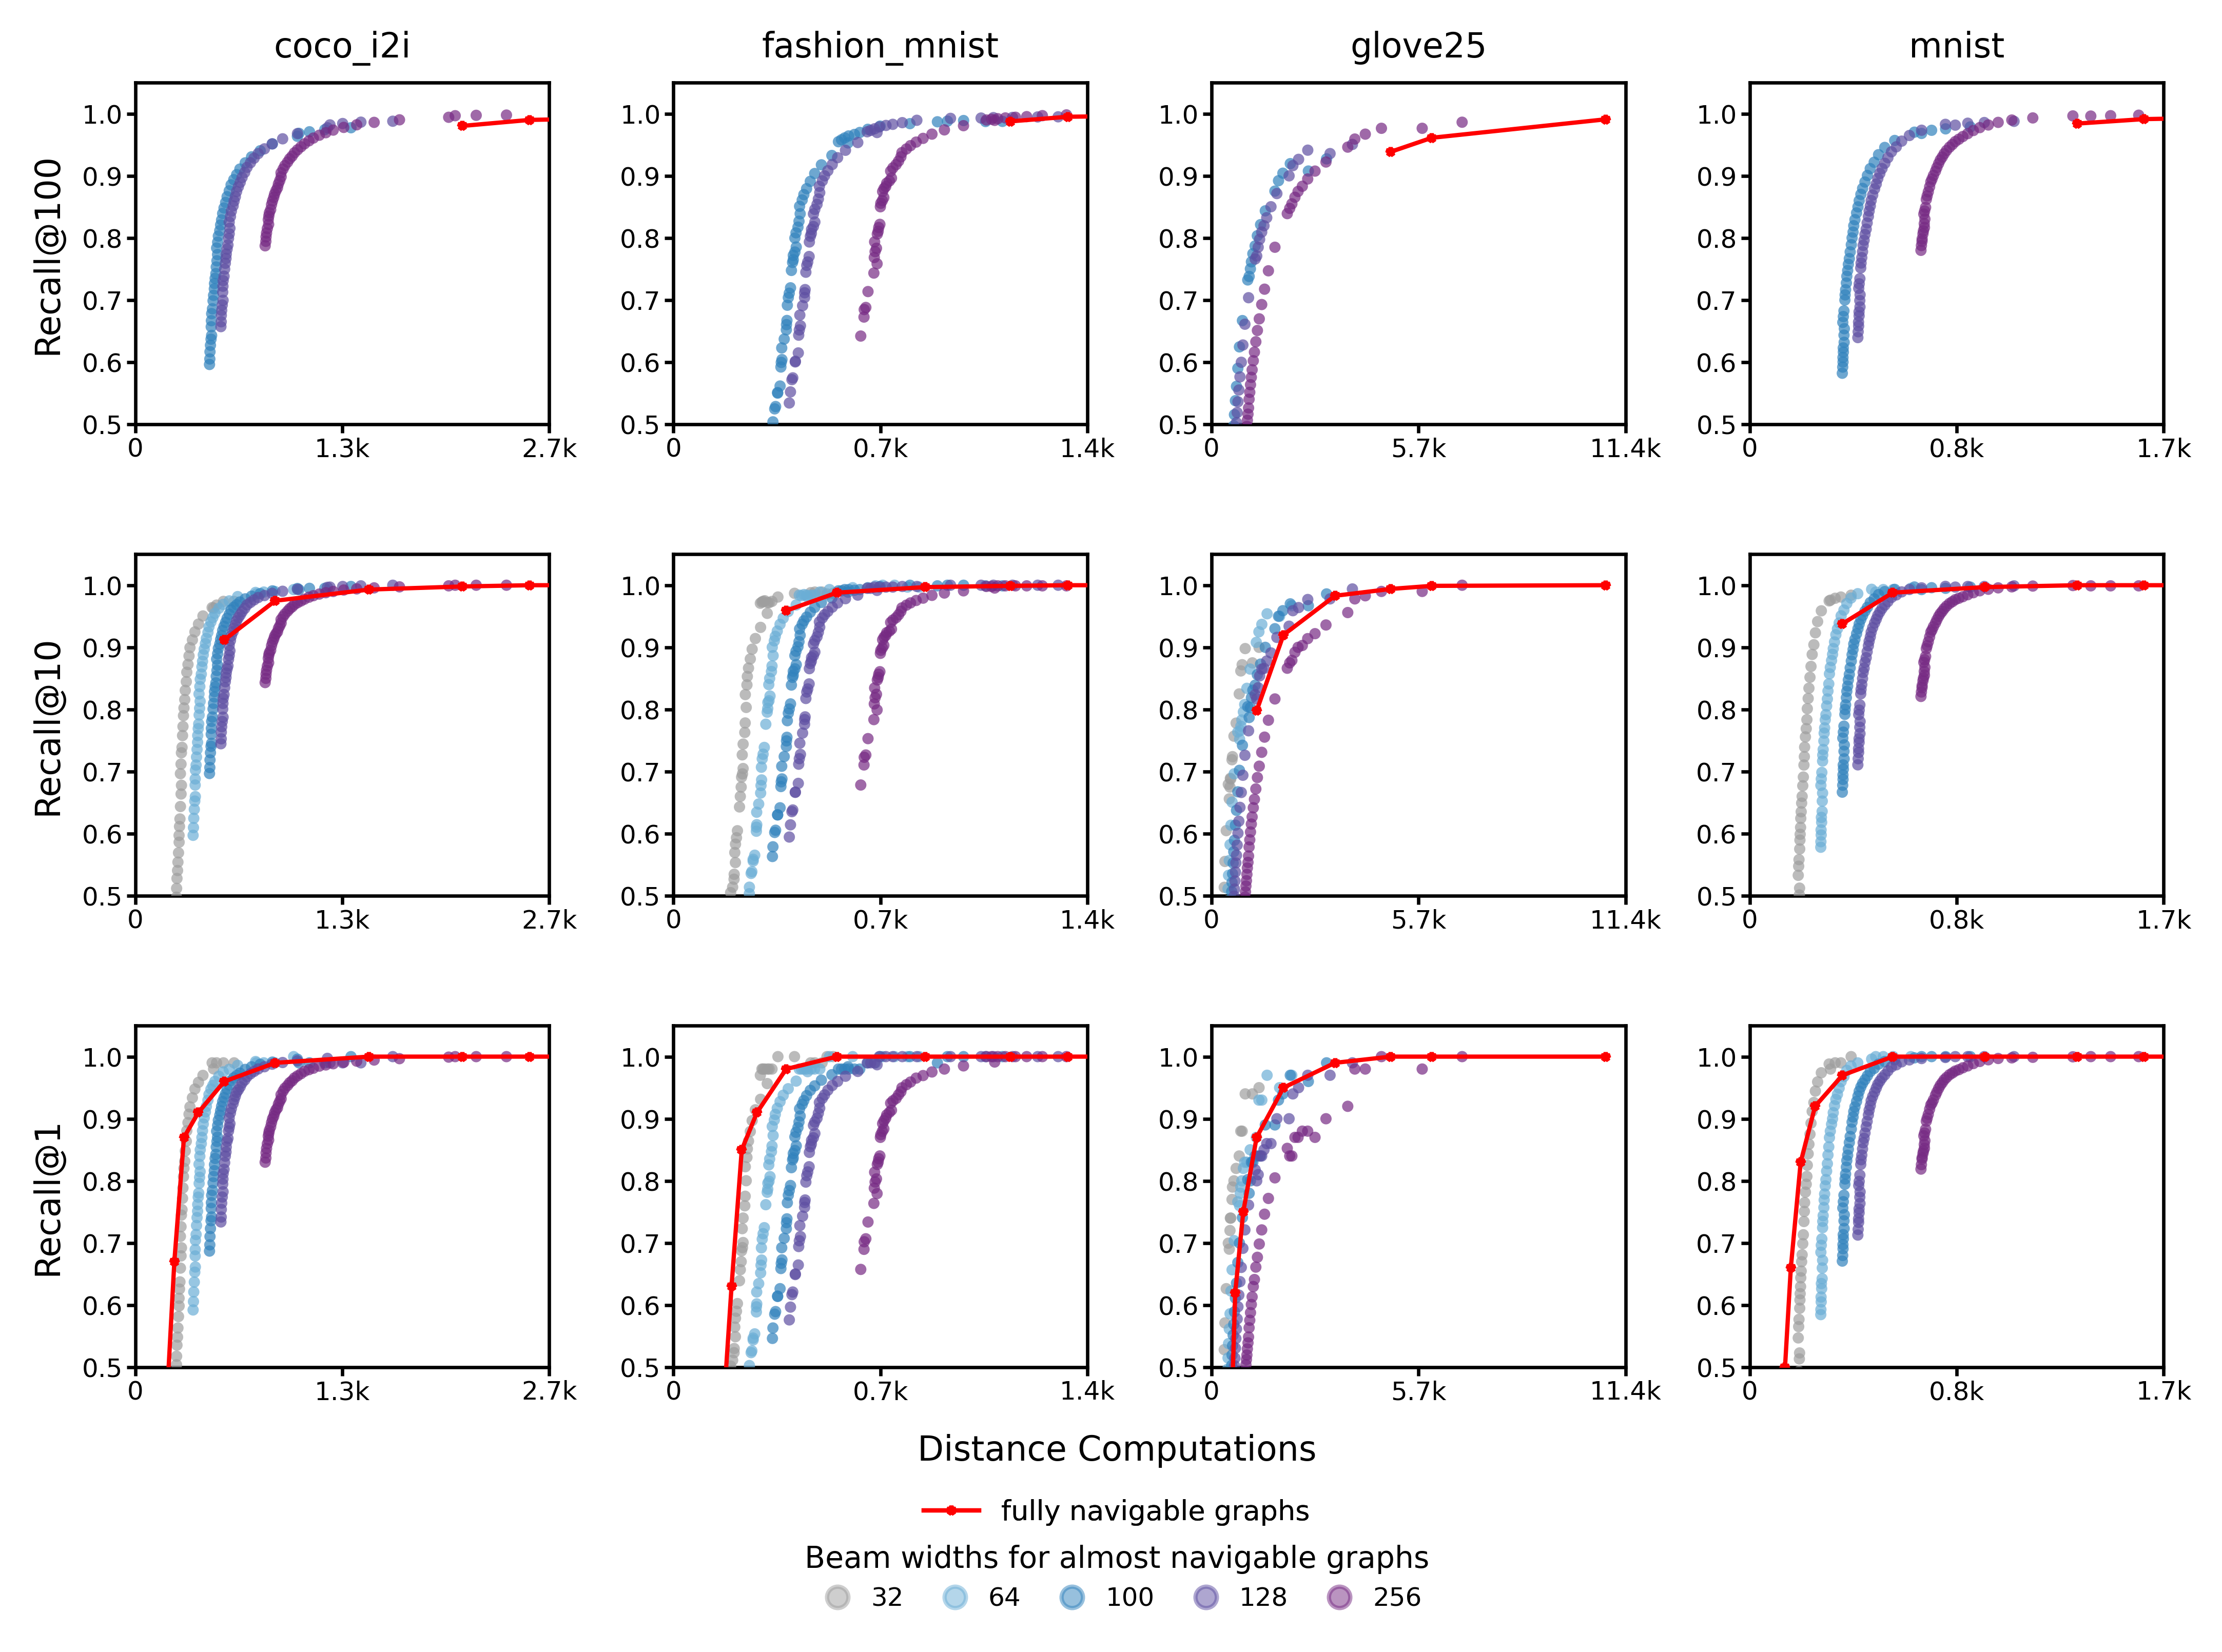

In [ ]:
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

def _k_formatter(x, pos):
    """Format axis ticks in thousands with a 'k' suffix: 500 -> 0.5k, 1000 -> 1k, 12500 -> 12.5k."""
    if x == 0:
        return '0'
    v = x / 1000.0
    s = f'{v:.1f}'.rstrip('0').rstrip('.')
    return f'{s}k'

# Scatter palette in hues of grey -> blue -> violet, ordered light-to-dark so increasing
# beam width reads as a darkening progression. Avoids reds/oranges so no beam-width color
# is confused with the red fully-navigable baseline line. (Black is reserved for Pareto.)
_CB_COLORS = [
    '#9E9E9E',  # grey
    '#6BAED6',  # light blue
    '#3182BD',  # blue
    '#5E4FA2',  # blue-violet
    '#762A83',  # violet
    # '#3F007D',  # deep violet
    '#525252',  # dark grey
    '#08519C',  # dark blue
]

def _bw_color(beam_widths):
    """Map each beam width -> a distinct color (single marker shape)."""
    return {bw: _CB_COLORS[i % len(_CB_COLORS)]
            for i, bw in enumerate(sorted(beam_widths))}

def _row_cutoff(curve, target=0.99):
    """x (train_seen) needed to show `curve`'s 0.99 crossing: the first train_seen
    where recall > target. If the curve never reaches target, return its last
    train_seen so the line still has a visible point. None for an empty curve."""
    if curve.empty:
        return None
    c = curve.sort_values('train_seen')
    hit = c[c['recall'] > target]
    return float(hit['train_seen'].iloc[0] if not hit.empty else c['train_seen'].iloc[-1])

def plot_recall_vs_seen_paper(df_novel, df_baseline, width_in=16.0, min_bw=32, save_path=None):
    """
    Compact, paper-ready figure: single figure, rows = k values, cols = datasets.
    - Scatter: only beam widths >= min_bw, one distinct color per beam width (single
      marker shape), reduced opacity. Colors are grey/blue/violet hues so they don't
      clash with the red baseline line.
    - Pareto frontier over those runs in black.
    - Fully-navigable curve (cov=1.0) in red: sweeps ALL beam widths >= k (so the low
      widths 1, 2, 4, ... appear, up through 256), with no markers.
    - For each Recall@k panel, runs with beam_width < k are dropped (a beam narrower
      than k can't return k neighbours).
    - Right x-limit is SHARED PER COLUMN (dataset): clips just after recall reaches 0.99,
      using the largest per-row cutoff in the column. Each row's cutoff is the LATER of
      its baseline / Pareto-frontier 0.99 crossings, so BOTH lines keep at least one
      visible point (their 0.99 crossing). A line that never reaches 0.99 contributes its
      last point instead. Falls back to the column's max train_seen if neither reaches it.
    - y-limit fixed to [0, 1.05] on every panel; y ticks at 0.2, 0.4, 0.6, 0.8, 1.0.
    - Two legends at the BOTTOM: the red/black line legend and the beam-width swatches.
    - x ticks in thousands with a 'k' suffix; exactly 3 per axis, first tick at 0.
    """
    datasets = sorted(df_novel['dataset'].unique())
    k_values = sorted(df_novel['k'].unique(), reverse=True)
    n_ds, n_k = len(datasets), len(k_values)

    plt.rcParams.update({
        'font.size': 7, 'axes.titlesize': 8, 'axes.labelsize': 8,
        'xtick.labelsize': 6, 'ytick.labelsize': 6, 'legend.fontsize': 7,
        'lines.linewidth': 1.2, 'lines.markersize': 2,
        'figure.dpi': 600, 'savefig.dpi': 600,
    })

    # only beam widths >= min_bw
    beam_widths = sorted(bw for bw in df_novel['beam_width'].unique() if bw >= min_bw)
    bw_color = _bw_color(beam_widths)

    cell_w = width_in / n_ds
    # Per-column shared x clipping (computed below) -> no automatic shared x axis.
    # Inter-panel spacing via gridspec wspace/hspace.
    fig, axes = plt.subplots(
        n_k, n_ds, figsize=(width_in, cell_w * 0.85 * n_k),
        squeeze=False,
        gridspec_kw={'wspace': 0.30, 'hspace': 0.38},
    )

    line_handles = None   # (red baseline, black pareto) captured once for the legend

    def panel_frames(nov_ds, base_ds, k):
        """The (scatter nov_k, baseline base_k, pareto frontier) for one (dataset, k)."""
        bw_floor = max(min_bw, k)
        nov_k  = nov_ds[(nov_ds['k'] == k) & (nov_ds['beam_width'] >= bw_floor)]
        # Fully-navigable curve: all beam widths >= k (sweeps the low widths the
        # scatter's min_bw filter excludes), including the largest width (256).
        base_k = base_ds[(base_ds['k'] == k) & (base_ds['beam_width'] >= k)] \
                   .sort_values('train_seen')
        frontier = pareto_frontier(
            nov_k[['train_seen', 'recall']].dropna(), 'train_seen', 'recall')
        return nov_k, base_k, frontier

    for c, dataset in enumerate(datasets):
        nov_ds  = df_novel[df_novel['dataset'] == dataset]
        base_ds = df_baseline[df_baseline['dataset'] == dataset]

        # Shared right x-limit for this column. Per row, take the LATER of the baseline
        # and frontier cutoffs so BOTH lines keep a visible point; then the column uses
        # the max across rows. Fall back to the column's max train_seen if no cutoff.
        row_cutoffs, col_seen_max = [], 0.0
        for k in k_values:
            nov_k, base_k, frontier = panel_frames(nov_ds, base_ds, k)
            cands = [s for s in (_row_cutoff(base_k), _row_cutoff(frontier)) if s is not None]
            if cands:
                row_cutoffs.append(max(cands))     # later crossing -> both lines visible
            col_seen_max = max(
                col_seen_max,
                float(nov_k['train_seen'].max() if not nov_k.empty else 0.0),
                float(base_k['train_seen'].max() if not base_k.empty else 0.0),
            )
        col_xmax = max(row_cutoffs) * 1.05 if row_cutoffs else col_seen_max

        for r, k in enumerate(k_values):
            ax = axes[r, c]
            nov_k, base_k, frontier = panel_frames(nov_ds, base_ds, k)

            # coverage<1 runs: one scatter per beam width, distinct color, single shape
            for bw in beam_widths:
                pts = nov_k[nov_k['beam_width'] == bw]
                if pts.empty:
                    continue
                ax.scatter(pts['train_seen'], pts['recall'],
                           color=bw_color[bw], marker='o', s=7, alpha=0.7,
                           edgecolors='none', zorder=3)

            # # Pareto frontier over those runs, in black
            # l_pareto, = ax.plot(frontier['train_seen'], frontier['recall'],
            #                     color='black', marker='', zorder=6,
            #                     label='pareto frontier of almost navigable graphs')

            # Fully-navigable curve (cov=1.0) in red -- no markers
            l_base, = ax.plot(base_k['train_seen'], base_k['recall'], linewidth=1,
                              color='red', marker='^', zorder=4,
                              label='fully navigable graphs')

            if line_handles is None:
                # line_handles = [l_base, l_pareto]
                line_handles = [l_base]

            # Shared per-column right x-limit; y in [0, 1.05] with ticks every 0.2 up to 1.0.
            if col_xmax > 0:
                ax.set_xlim(0, col_xmax)
                ax.xaxis.set_major_locator(
                    mticker.FixedLocator([0, col_xmax / 2, col_xmax]))
            ax.xaxis.set_major_formatter(mticker.FuncFormatter(_k_formatter))
            ax.set_ylim(0.5, 1.05)
            ax.yaxis.set_major_locator(mticker.FixedLocator([0.5, 0.6, 0.7, 0.8, 0.9, 1.0]))

            if r == 0:
                ax.set_title(dataset)
            if c == 0:
                ax.set_ylabel(f'Recall@{k}')
            ax.tick_params(length=2, pad=1)

    fig.supxlabel('Distance Computations', fontsize=8, y=0.05)

    # Two bottom legends: (1) the red/black line legend, (2) beam-width swatches.
    leg_lines = fig.legend(handles=line_handles, loc='lower center', ncol=2,
                           bbox_to_anchor=(0.5, 0.0), frameon=False, fontsize=6.5)
    fig.add_artist(leg_lines)

    bw_handles = [
        Line2D([0], [0], color=bw_color[bw], marker='o', alpha=0.5,
               linestyle='none', markersize=5, label=f'{bw}')
        for bw in beam_widths
    ]
    fig.legend(handles=bw_handles, title='Beam widths for almost navigable graphs', loc='lower center',
               bbox_to_anchor=(0.5, -0.05), ncol=len(bw_handles), frameon=False,
               fontsize=6, title_fontsize=7, handletextpad=0.3, columnspacing=1.0)

    fig.tight_layout(rect=(0, 0.10, 1, 1))
    if save_path:
        fig.savefig(save_path, bbox_inches='tight')
    plt.show()

plot_recall_vs_seen_paper(
    novel, baseline, width_in=8.5, min_bw=32, save_path='recall_vs_seen_paper.pdf')

In [ ]:
def plot_degree_vs_coverage_paper(df_long, width_in=7.0, save_path=None):
    """
    Compact, paper-ready figure: one subplot per dataset (single row).
    Avg. out-degree (y) vs coverage (x). avg_edges depends only on (dataset, coverage),
    so it collapses to one curve per dataset (independent of beam_width / k).
    x-axis ticks snapped to nearest 0.01; y-axis spans [0, ceil(max degree)] with 5 ticks;
    one shared x-label. x-limits have slack so endpoint markers aren't clipped.
    """
    datasets = sorted(df_long['dataset'].unique())
    n_ds = len(datasets)

    plt.rcParams.update({
        'font.size': 7, 'axes.titlesize': 8, 'axes.labelsize': 8,
        'xtick.labelsize': 4.5, 'ytick.labelsize': 4.5, 'legend.fontsize': 7,
        'lines.linewidth': 1.0, 'lines.markersize': 2,
        'figure.dpi': 200, 'savefig.dpi': 600,
    })

    cell_w = width_in / n_ds
    fig, axes = plt.subplots(1, n_ds, figsize=(width_in, cell_w * 0.85), squeeze=False)

    for c, dataset in enumerate(datasets):
        ax = axes[0, c]
        # One avg_edges per (dataset, coverage) — collapse duplicates across bw / k
        curve = (
            df_long[df_long['dataset'] == dataset]
            .groupby('coverage', as_index=False)['avg_edges']
            .first()
            .sort_values('coverage')
        )

        ax.plot(curve['coverage'], curve['avg_edges'],
                color='black', marker='o', zorder=3)

        # x: 5 ticks snapped to the nearest 0.01, within [cmin, cmax] + slack on the limits
        cmin, cmax = curve['coverage'].min(), curve['coverage'].max()
        xticks = np.unique(np.round(np.linspace(cmin, cmax, 5), 2))
        xpad = 0.03 * (cmax - cmin)
        ax.set_xlim(cmin - xpad, cmax + xpad)
        ax.xaxis.set_major_locator(mticker.FixedLocator(xticks))
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:g}'))

        # y: 5 ticks spanning [0, ceil(max degree)]
        ytop = np.ceil(curve['avg_edges'].max())
        yticks = np.round(np.linspace(0, ytop, 5))
        ax.set_ylim(0, ytop)
        ax.yaxis.set_major_locator(mticker.FixedLocator(yticks))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, p: f'{y:g}'))

        ax.set_title(dataset)
        if c == 0:
            ax.set_ylabel('Avg. Out-Degree')
        ax.tick_params(length=2, pad=1)

    # Single shared x-axis label
    fig.supxlabel(r'Coverage $= (1 - \gamma)$', fontsize=8)

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches='tight')
    plt.show()

plot_degree_vs_coverage_paper(df_long, width_in=7.0, save_path='degree_vs_coverage_paper.pdf')

In [ ]:
# Per-dataset target recalls: glove25 saturates lower, so it uses a lower band.
DEFAULT_TARGET_RECALLS = [0.9, 0.95, 0.97, 0.99]
TARGET_RECALLS_BY_DATASET = {
    # 'glove25': [0.8, 0.85],
}
K_VALUES = [1, 10, 100]

# A curve whose max recall falls within RECALL_TOL below a target is treated as
# reaching that target (snap to its highest-recall point) rather than blanked.
# e.g. an almost-navigable frontier maxing out at 0.9894 still fills the 0.99 row.
RECALL_TOL = 0.01

def build_comparison_table(df_long,
                           default_targets=DEFAULT_TARGET_RECALLS,
                           targets_by_dataset=TARGET_RECALLS_BY_DATASET,
                           k_values=K_VALUES):
    """
    Wide layout: one row per (dataset, target recall). For each target, full detail
    -- Fully, Almost, the almost/fully Ratio, and gamma -- is reported for both distance
    computations and average degree, for every k in `k_values` (recall@1, @10, @100).

    Fully-navigable = coverage=1.0 baseline (beam-width sweep). Almost-navigable =
    Pareto frontier over the coverage<1.0 runs.

      - Distance computations: interpolate train_seen as a function of recall along the
        curve (ordered by train_seen => recall increases). If the target exceeds the
        curve's max recall by <= RECALL_TOL, snap to the highest-recall point; else NaN.
      - Average degree: avg_edges of the curve point whose recall is nearest the target
        (same reach test, so a per-k cell is blank or populated consistently).
      - gamma = coverage of the Almost-navigable (Pareto frontier) point whose recall
        is nearest the target. One gamma per @k (shared across both metrics). NaN if the
        almost curve does not reach the target.

    Columns:
      dataset, target recall,
      dist {fully,almost,ratio} @{k}  for k in k_values,
      deg  {fully,almost,ratio} @{k}  for k in k_values,
      gamma @{k}                      for k in k_values.
    """
    datasets = sorted(df_long['dataset'].unique())

    def seen_at_recall(curve, target, tol=RECALL_TOL):
        c = curve.sort_values('train_seen')
        rec  = c['recall'].to_numpy()
        seen = c['train_seen'].to_numpy()
        if len(c) == 0 or target < rec.min() or target > rec.max() + tol:
            return np.nan
        # np.interp clamps above rec.max() to seen at the max-recall endpoint.
        return float(np.interp(target, rec, seen))

    def degree_nearest_recall(curve, target, tol=RECALL_TOL):
        if curve.empty or target < curve['recall'].min() or target > curve['recall'].max() + tol:
            return np.nan
        idx = (curve['recall'] - target).abs().idxmin()
        return float(curve.loc[idx, 'avg_edges'])

    def gamma_nearest_recall(curve, target, tol=RECALL_TOL):
        """coverage of the curve point whose recall is nearest `target`. Same reach
        test as degree_nearest_recall, so gamma is populated iff the almost cells are."""
        if curve.empty or target < curve['recall'].min() or target > curve['recall'].max() + tol:
            return np.nan
        idx = (curve['recall'] - target).abs().idxmin()
        return float(curve.loc[idx, 'coverage'])

    def detail_for(dk, target):
        """For one (dataset,k) slice at `target`, return per-metric
        (fully, almost, ratio) tuples for distance computations and average degree,
        plus gamma (coverage of the chosen almost point)."""
        full = dk[dk['coverage'] == 1.0][['recall', 'train_seen', 'avg_edges']].dropna()
        nov  = dk[dk['coverage'] <  1.0][['recall', 'train_seen', 'avg_edges', 'coverage']].dropna()
        if full.empty or nov.empty:
            nan3 = (np.nan, np.nan, np.nan)
            return nan3, nan3, np.nan
        almost = pareto_frontier(nov, 'train_seen', 'recall')

        full_seen, alm_seen = seen_at_recall(full, target), seen_at_recall(almost, target)
        full_deg,  alm_deg  = degree_nearest_recall(full, target), degree_nearest_recall(almost, target)
        gamma = gamma_nearest_recall(almost, target)

        seen_ratio = (alm_seen / full_seen
                      if np.isfinite(full_seen) and np.isfinite(alm_seen) and full_seen else np.nan)
        deg_ratio  = (alm_deg / full_deg
                      if np.isfinite(full_deg) and np.isfinite(alm_deg) and full_deg else np.nan)
        return (full_seen, alm_seen, seen_ratio), (full_deg, alm_deg, deg_ratio), gamma

    rows = []
    for dataset in datasets:
        ds = df_long[df_long['dataset'] == dataset]
        targets = targets_by_dataset.get(dataset, default_targets)
        for tr in targets:
            row = {'dataset': dataset, 'target recall': tr}
            for k in k_values:
                dk = ds[ds['k'] == k]
                if dk.empty:
                    (fs, as_, sr), (fd, ad, dr), gm = (np.nan,)*3, (np.nan,)*3, np.nan
                else:
                    (fs, as_, sr), (fd, ad, dr), gm = detail_for(dk, tr)
                row[f'dist fully @{k}'] = fs
                row[f'dist almost @{k}'] = as_
                row[f'dist ratio @{k}'] = sr
                row[f'deg fully @{k}'] = fd
                row[f'deg almost @{k}'] = ad
                row[f'deg ratio @{k}'] = dr
                row[f'gamma @{k}'] = gm
            rows.append(row)

    cols = ['dataset', 'target recall']
    for k in k_values:
        cols += [f'dist fully @{k}', f'dist almost @{k}', f'dist ratio @{k}']
    for k in k_values:
        cols += [f'deg fully @{k}', f'deg almost @{k}', f'deg ratio @{k}']
    for k in k_values:
        cols += [f'gamma @{k}']
    return pd.DataFrame(rows, columns=cols)

comparison_table = build_comparison_table(df_long)
comparison_table.round(3)


In [ ]:
def comparison_table_to_latex(df, metric, k_values=K_VALUES, caption=None, label=None):
    r"""
    Wide target-recall table (table*, booktabs + multirow) for a single metric --
    `metric` is 'dist' (Distance Computations) or 'deg' (Average Degree). One row per
    (dataset, target recall); Dataset cell spans its target rows. Split into
    recall@1/@10/@100, each @k block carrying Fully / Almost / Ratio / gamma.
    NaN prints as '-'.

    gamma = coverage of the almost-navigable point chosen at that @k. The Dataset
    and Target Recall columns are repeated in the distance and degree tables.

    Horizontal \cmidrule rules group the @k blocks; no vertical separators.
    Requires \usepackage{booktabs} and \usepackage{multirow}.
    """
    metric_title = {'dist': 'Distance Computations', 'deg': 'Average Degree'}[metric]
    val_fmt = {'dist': '.0f', 'deg': '.2f'}[metric]

    n_k = len(k_values)
    sub = 4  # Fully, Almost, Ratio, gamma per @k
    block = n_k * sub
    # dataset, target, then [@1 @10 @100] for this metric (no vrules)
    col_fmt = 'l' + 'c' + 'r' * block

    def tex(s):
        return str(s).replace('_', r'\_')

    def num(v, fmt):
        return '-' if pd.isna(v) else format(v, fmt)

    def fmt_cells(r):
        cells = [num(r['target recall'], '.2f')]
        for k in k_values:
            cells += [num(r[f'{metric} fully @{k}'],  val_fmt),
                      num(r[f'{metric} almost @{k}'], val_fmt),
                      num(r[f'{metric} ratio @{k}'],  '.2f'),
                      num(r[f'gamma @{k}'],           '.5f')]
        return cells

    # 1-based column bookkeeping (Dataset + Target occupy cols 1,2)
    metric_start = 3

    # row 1: metric super-column
    super_hdr = (r'\multirow{3}{*}{\textbf{Dataset}} & \multirow{3}{*}{\textbf{Target Recall}} & '
                 rf'\multicolumn{{{block}}}{{c}}{{\textbf{{{metric_title}}}}} \\')
    super_rule = rf'\cmidrule(lr){{{metric_start}-{metric_start + block - 1}}}'

    # row 2: one \multicolumn{sub}{c}{@k} per k
    k_hdr = '& & ' + ' & '.join(
        rf'\multicolumn{{{sub}}}{{c}}{{\textbf{{$k = {k}$}}}}' for k in k_values
    ) + r' \\'
    k_rules, col = [], metric_start
    for _ in range(n_k):
        k_rules.append(rf'\cmidrule(lr){{{col}-{col + sub - 1}}}')
        col += sub
    k_rule = ' '.join(k_rules)

    # row 3: Fully / Almost / Ratio / gamma sub-labels under every @k
    far = r'\textbf{F} & \textbf{A} & \textbf{R} & \boldmath$\gamma$'
    sub_hdr = '& & ' + ' & '.join([far] * n_k) + r' \\'

    lines = [
        r'\begin{table*}[t]', r'\centering', r'\scriptsize',
        r'\setlength{\tabcolsep}{3pt}',
        rf'\begin{{tabular}}{{{col_fmt}}}',
        r'\toprule',
        super_hdr,
        super_rule,
        k_hdr,
        k_rule,
        sub_hdr,
        r'\midrule',
    ]

    datasets = list(dict.fromkeys(df['dataset']))
    for di, dataset in enumerate(datasets):
        ds = df[df['dataset'] == dataset]
        ds_cell = rf'\multirow{{{len(ds)}}}{{*}}{{{tex(dataset)}}}'
        for ri, (_, r) in enumerate(ds.iterrows()):
            lead = ds_cell if ri == 0 else ''
            lines.append(' & '.join([lead] + fmt_cells(r)) + r' \\')
        if di < len(datasets) - 1:
            lines.append(r'\midrule')

    lines += [r'\bottomrule', r'\end{tabular}']
    if caption:
        lines.append(rf'\caption{{{caption}}}')
    if label:
        lines.append(rf'\label{{{label}}}')
    lines.append(r'\end{table*}')
    return '\n'.join(lines)


_far_legend = (r'Each block reports Fully-navigable (F, coverage $=1$), '
               r'Almost-navigable (A, Pareto frontier over coverage $<1$), '
               r'their ratio R\,$=$\,A\,/\,F, and $\gamma$ (coverage of the chosen '
               r'almost-navigable point. `-` marks a target recall the curve does not reach.')

dist_latex = comparison_table_to_latex(
    comparison_table, 'dist',
    caption=(r'Distance computations to reach each target recall, broken out by '
             r'Recall@$k$ ($k\in\{1,10,100\}$). ' + _far_legend),
    label='tab:target-recall-dist',
)
deg_latex = comparison_table_to_latex(
    comparison_table, 'deg',
    caption=(r'Average degree to reach each target recall, broken out by '
             r'Recall@$k$ ($k\in\{1,10,100\}$). ' + _far_legend),
    label='tab:target-recall-deg',
)
print(dist_latex)
print()
print(deg_latex)


In [ ]:
from IPython.display import HTML

def comparison_table_to_html(df, metric, k_values=K_VALUES):
    """
    Inline preview of a single-metric target-recall table -- `metric` is 'dist'
    (Distance Computations) or 'deg' (Average Degree). Dataset cell merged across its
    target rows; split into recall@1/@10/@100, each @k carrying Fully / Almost / Ratio /
    gamma. NaN shown as '-'. gamma = coverage of the chosen almost point.

    The Dataset and Target Recall columns are repeated across the dist and deg tables.
    """
    metric_title = {'dist': 'Distance Computations', 'deg': 'Average Degree'}[metric]
    vfmt = {'dist': '.0f', 'deg': '.2f'}[metric]

    css = """
    <style>
    table.cmp { border-collapse: collapse; font-family: serif; font-size: 11px; }
    table.cmp th, table.cmp td { padding: 2px 6px; text-align: right; }
    table.cmp th { border-bottom: 1px solid #000; }
    table.cmp td.lbl { text-align: left; vertical-align: middle; border-right: 1px solid #ddd; }
    table.cmp tr.dsstart td { border-top: 1.5px solid #000; }   /* between datasets */
    table.cmp .grp { border-left: 1px solid #bbb; }             /* @k block edge */
    table.cmp .tgt { border-right: 1px solid #888; }            /* Target | metric edge */
    </style>
    """
    n_k = len(k_values)

    def num(v, fmt):
        return '-' if pd.isna(v) else format(v, fmt)

    def numcells(r):
        # target recall (right border), then per k -> (fully, almost, ratio, gamma)
        out = [f'<td class="num tgt">{num(r["target recall"], ".2f")}</td>']
        for i, k in enumerate(k_values):
            edge = 'grp' if i == 0 else ''  # border at each @k block start
            out.append(f'<td class="num {edge}">{num(r[f"{metric} fully @{k}"], vfmt)}</td>')
            out.append(f'<td class="num">{num(r[f"{metric} almost @{k}"], vfmt)}</td>')
            out.append(f'<td class="num">{num(r[f"{metric} ratio @{k}"], ".2f")}</td>')
            out.append(f'<td class="num">{num(r[f"gamma @{k}"], ".5f")}</td>')
        return ''.join(out)

    # row 2: @k spanning 4 sub-cols each; row 3: F / A / R / gamma
    k_row = ''.join(
        f'<th class="{"grp" if i == 0 else ""}" colspan="4">@{k}</th>'
        for i, k in enumerate(k_values)
    )
    far_row = ''.join(
        f'<th class="{"grp" if i == 0 else ""}">F</th><th>A</th><th>R</th><th>&gamma;</th>'
        for i in range(n_k)
    )
    block = 4 * n_k
    head = (
        '<tr>'
        '<th rowspan="3">Dataset</th><th rowspan="3" class="tgt">Target</th>'
        f'<th colspan="{block}">{metric_title}</th>'
        '</tr>'
        f'<tr>{k_row}</tr>'
        f'<tr>{far_row}</tr>'
    )

    body = []
    datasets = list(dict.fromkeys(df['dataset']))
    for dataset in datasets:
        ds = df[df['dataset'] == dataset]
        for ri, (_, r) in enumerate(ds.iterrows()):
            cls = 'dsstart' if ri == 0 else ''
            tr = f'<tr class="{cls}">'
            cells = ''
            if ri == 0:
                cells += f'<td class="lbl" rowspan="{len(ds)}">{dataset}</td>'
            cells += numcells(r)
            body.append(tr + cells + '</tr>')

    return HTML(css + '<table class="cmp">' + head + ''.join(body) + '</table>')

from IPython.display import display
display(comparison_table_to_html(comparison_table, 'dist'))
display(comparison_table_to_html(comparison_table, 'deg'))


In [ ]:
# Ratio-only view: drop the Fully / Almost columns, keep just the almost/fully ratio
# per metric per k. Reuses the full `comparison_table` built above.
#
# Each value is the almost-navigable cost RELATIVE TO the fully-navigable graph
# (almost / fully) to reach the target recall: < 1 means lower coverage is cheaper,
# >= 1 (italicised) means lower coverage is no better than full coverage.

def ratio_table_to_latex(df, k_values=K_VALUES, caption=None, label=None):
    """
    Compact ratio-only table: each cell is almost-navigable / fully-navigable. One row
    per (dataset, target recall). Two super-columns -- 'Ratio of Distance Computations'
    and 'Ratio of Average Degree' -- split into k = 1/10/100. Headers are bold; ratios
    >= 1 (lower coverage no better than full) are italicised. NaN prints as '-'.
    A final 'Average' row reports the column-wise mean across all non-NaN entries.
    Requires \\usepackage{booktabs}, \\usepackage{multirow}.
    """
    n_k = len(k_values)
    # Use @{} to suppress inter-column space at the boundary between the two metric
    # super-columns; this ensures no gap bleeds into the dist or deg blocks.
    # Fixed equal-width centred columns for every k cell so that no column
    # auto-expands to its widest entry ($k = 100$ vs $k = 1$); this keeps the
    # inner spacing within each super-column uniform.
    kcol = r'>{\centering\arraybackslash}p{1.6cm}'
    col_fmt = 'l' + 'c' + kcol * n_k + kcol * n_k

    def tex(s):
        return str(s).replace('_', r'\_')

    def num(v, fmt):
        return '-' if pd.isna(v) else format(v, fmt)

    def ratio(v):
        """Format a ratio cell; italicise when >= 1 (lower coverage failed to help)."""
        if pd.isna(v):
            return '-'
        s = format(v, '.2f')
        return rf'\textit{{{s}}}' if v >= 1 else s

    def fmt_cells(r):
        cells = [num(r['target recall'], '.2f')]
        cells += [ratio(r[f'dist ratio @{k}']) for k in k_values]
        cells += [ratio(r[f'deg ratio @{k}'])  for k in k_values]
        return cells

    dist_start = 3
    deg_start  = dist_start + n_k
    k_header = ' & '.join(rf'\textbf{{$k = {k}$}}' for k in k_values)

    lines = [
        r'\begin{table*}[t]', r'\centering', r'\small',
        r'\setlength{\tabcolsep}{6pt}',
        rf'\begin{{tabular}}{{{col_fmt}}}',
        r'\toprule',
        (r'\multirow{2}{*}{\textbf{Dataset}} & \multirow{2}{*}{\textbf{Target Recall}} & '
         rf'\multicolumn{{{n_k}}}{{c}}{{\textbf{{Ratio of Distance Computations}}}} & '
         rf'\multicolumn{{{n_k}}}{{c}}{{\textbf{{Ratio of Average Degree}}}} \\'),
        (rf'\cmidrule(r){{{dist_start}-{dist_start + n_k - 1}}} '
         rf'\cmidrule(l){{{deg_start}-{deg_start + n_k - 1}}}'),
        rf'& & {k_header} & {k_header} \\',
        r'\midrule',
    ]

    datasets = list(dict.fromkeys(df['dataset']))
    for di, dataset in enumerate(datasets):
        ds = df[df['dataset'] == dataset]
        ds_cell = rf'\multirow{{{len(ds)}}}{{*}}{{{tex(dataset)}}}'
        for ri, (_, r) in enumerate(ds.iterrows()):
            lead = ds_cell if ri == 0 else ''
            lines.append(' & '.join([lead] + fmt_cells(r)) + r' \\')
        if di < len(datasets) - 1:
            lines.append(r'\midrule')

    # Average row: column-wise mean of all non-NaN ratio values
    avg_cells = [r'\textbf{Average}', '']
    for metric in ('dist', 'deg'):
        for k in k_values:
            col = f'{metric} ratio @{k}'
            vals = pd.to_numeric(df[col], errors='coerce').dropna()
            avg_cells.append(ratio(vals.mean()) if not vals.empty else '-')
    lines.append(r'\midrule')
    lines.append(' & '.join(avg_cells) + r' \\')

    lines += [r'\bottomrule', r'\end{tabular}']
    if caption:
        lines.append(rf'\caption{{{caption}}}')
    if label:
        lines.append(rf'\label{{{label}}}')
    lines.append(r'\end{table*}')
    return '\n'.join(lines)


def ratio_table_to_html(df, k_values=K_VALUES):
    """Inline preview of the ratio-only table (almost / fully). Ratios >= 1 italicised."""
    css = """
    <style>
    table.cmp { border-collapse: collapse; font-family: serif; font-size: 12px; }
    table.cmp th, table.cmp td { padding: 2px 8px; text-align: right; }
    table.cmp th { border-bottom: 1px solid #000; }
    table.cmp td.lbl { text-align: left; vertical-align: middle; border-right: 1px solid #ddd; }
    table.cmp tr.dsstart td { border-top: 1.5px solid #000; }
    table.cmp tr.avgrow td { border-top: 1.5px solid #000; font-weight: bold; }
    table.cmp .grp { border-left: 1px solid #bbb; }
    table.cmp .tgt { border-right: 1px solid #888; }
    </style>
    """
    n_k = len(k_values)

    def num(v, fmt):
        return '-' if pd.isna(v) else format(v, fmt)

    def ratio(v):
        """Format a ratio cell; italicise when >= 1 (lower coverage failed to help)."""
        if pd.isna(v):
            return '-'
        s = format(v, '.2f')
        return f'<em>{s}</em>' if v >= 1 else s

    def numcells(r):
        out = [f'<td class="num tgt">{num(r["target recall"], ".2f")}</td>']
        for metric in ('dist', 'deg'):
            for i, k in enumerate(k_values):
                edge = 'grp' if i == 0 else ''
                out.append(f'<td class="num {edge}">{ratio(r[f"{metric} ratio @{k}"])}</td>')
        return ''.join(out)

    k_sub = lambda: ''.join(
        f'<th class="{"grp" if i == 0 else ""}">k = {k}</th>' for i, k in enumerate(k_values)
    )
    head = (
        '<tr>'
        '<th rowspan="2">Dataset</th><th rowspan="2" class="tgt">Target Recall</th>'
        f'<th colspan="{n_k}">Ratio of Distance Computations</th>'
        f'<th colspan="{n_k}">Ratio of Average Degree</th>'
        '</tr>'
        f'<tr>{k_sub()}{k_sub()}</tr>'
    )

    body = []
    for dataset in dict.fromkeys(df['dataset']):
        ds = df[df['dataset'] == dataset]
        for ri, (_, r) in enumerate(ds.iterrows()):
            cls = 'dsstart' if ri == 0 else ''
            cells = ''
            if ri == 0:
                cells += f'<td class="lbl" rowspan="{len(ds)}">{dataset}</td>'
            cells += numcells(r)
            body.append(f'<tr class="{cls}">' + cells + '</tr>')

    # Average row
    avg_cells = '<td class="lbl"><strong>Average</strong></td><td class="tgt"></td>'
    for metric in ('dist', 'deg'):
        for i, k in enumerate(k_values):
            col = f'{metric} ratio @{k}'
            vals = pd.to_numeric(df[col], errors='coerce').dropna()
            v = vals.mean() if not vals.empty else float('nan')
            edge = 'grp' if i == 0 else ''
            avg_cells += f'<td class="num {edge}">{ratio(v)}</td>'
    body.append(f'<tr class="avgrow">{avg_cells}</tr>')

    return HTML(css + '<table class="cmp">' + head + ''.join(body) + '</table>')


print(ratio_table_to_latex(
    comparison_table,
    caption=(r'Ratio of the almost-navigable graph to the fully-navigable one '
             r'(value $=$ almost-navigable $/$ fully-navigable) in distance computations '
             r'and average degree to reach each target recall, by $k$ '
             r'($k\in\{1,10,100\}$). Values $< 1$ mean lower coverage is cheaper; values '
             r'$\geq 1$ (italicised) mean lower coverage is no better than full coverage. '
             r'`-` marks a target recall the curve does not reach.'),
    label='tab:target-recall-ratio',
))
ratio_table_to_html(comparison_table)


In [72]:
def coverage_stats_to_latex(csv_path='../coverage_stats.csv',
                            coverages=(100.0, 99.99, 99.95, 99.5, 95.0), cov_range=None,
                            method='robust-prune', caption=None, label=None):
    stats = pd.read_csv(csv_path)
    if cov_range is not None:
        lo, hi = cov_range
        cov_mask = stats['coverage'].between(lo, hi)
    else:
        cov_mask = stats['coverage'].isin(coverages)
    f = (stats[(stats['method'] == method) & cov_mask]
         .drop(columns=['method', 'metric'])
         .sort_values(['dataset', 'coverage'], ascending=[True, False])
         .reset_index(drop=True))

    # centred numeric columns: dataset | points dim cov | out(4) | in(3)
    col_fmt = 'l' + 'ccc' + 'cccc' + 'ccc'

    def tex(s):
        return str(s).replace('_', r'\_')

    def fmt_row(r, span=None):
        # Points and Dim. are constant per dataset: \multirow on the first row, blank after.
        if span is not None:
            pts = rf"\multirow{{{span}}}{{*}}{{{int(r['total points']):,}}}"
            dim = rf"\multirow{{{span}}}{{*}}{{{int(r['dimensions'])}}}"
        else:
            pts, dim = '', ''
        return [
            pts,
            dim,
            f"{r['coverage']/100:.5f}",
            # out-degree: mean, median, min, max
            f"{r['mean out degree']:.2f}",
            f"{r['median out degree']:.1f}",
            f"{int(r['min out degree'])}",
            f"{int(r['max out degree'])}",
            # in-degree: median, min, max (CSV has no mean in degree)
            f"{r['median in degree']:.1f}",
            f"{int(r['min in degree'])}",
            f"{int(r['max in degree'])}",
        ]

    # leading label headers span both header rows (vertically centred)
    h_dataset = r'\multirow{2}{*}{Dataset}'
    h_points  = r'\multirow{2}{*}{Points}'
    h_dim     = r'\multirow{2}{*}{Dim.}'
    h_cov     = r'\multirow{2}{*}{$\gamma$}'

    lines = [
        r'\begin{table*}[t]', r'\centering', r'\small',
        r'\setlength{\tabcolsep}{4pt}',
        rf'\begin{{tabular}}{{{col_fmt}}}',
        r'\toprule',
        rf'{h_dataset} & {h_points} & {h_dim} & {h_cov} & '
        r'\multicolumn{4}{c}{Out-degree} & \multicolumn{3}{c}{In-degree} \\',
        r'\cmidrule(lr){5-8} \cmidrule(lr){9-11}',
        r'& & & & Mean & Median & Min & Max & Median & Min & Max \\',
        r'\midrule',
    ]

    datasets = list(dict.fromkeys(f['dataset']))
    for di, ds in enumerate(datasets):
        grp = f[f['dataset'] == ds]
        n = len(grp)
        ds_cell = rf'\multirow{{{n}}}{{*}}{{{tex(ds)}}}'
        for ri, (_, r) in enumerate(grp.iterrows()):
            lead = ds_cell if ri == 0 else ''
            cells = fmt_row(r, span=n if ri == 0 else None)
            lines.append(' & '.join([lead] + cells) + r' \\')
        if di < len(datasets) - 1:
            lines.append(r'\cmidrule(l){2-11}')

    lines += [r'\bottomrule', r'\end{tabular}']
    if caption:
        lines.append(rf'\caption{{{caption}}}')
    if label:
        lines.append(rf'\label{{{label}}}')
    lines.append(r'\end{table*}')
    return '\n'.join(lines)


print(coverage_stats_to_latex(
    # cov_range=(95, 100),
    caption=(r'Graph out-degree and in-degree statistics for robust-prune runs at '
             r'various coverage levels.'),
    label='tab:coverage-stats',
))

\begin{table*}[t]
\centering
\small
\setlength{\tabcolsep}{4pt}
\begin{tabular}{lcccccccccc}
\toprule
\multirow{2}{*}{Dataset} & \multirow{2}{*}{Points} & \multirow{2}{*}{Dim.} & \multirow{2}{*}{$\gamma$} & \multicolumn{4}{c}{Out-degree} & \multicolumn{3}{c}{In-degree} \\
\cmidrule(lr){5-8} \cmidrule(lr){9-11}
& & & & Mean & Median & Min & Max & Median & Min & Max \\
\midrule
\multirow{3}{*}{coco\_i2i} & \multirow{3}{*}{113,287} & \multirow{3}{*}{512} & 1.00000 & 28.59 & 27.0 & 2 & 131 & 24.0 & 1 & 268 \\
 &  &  & 0.99500 & 13.54 & 12.0 & 2 & 75 & 13.0 & 1 & 87 \\
 &  &  & 0.95000 & 6.69 & 6.0 & 2 & 52 & 6.0 & 1 & 49 \\
\cmidrule(l){2-11}
\multirow{5}{*}{fashion\_mnist} & \multirow{5}{*}{60,000} & \multirow{5}{*}{784} & 1.00000 & 13.55 & 12.0 & 1 & 108 & 12.0 & 1 & 117 \\
 &  &  & 0.99990 & 12.13 & 11.0 & 1 & 107 & 11.0 & 1 & 70 \\
 &  &  & 0.99950 & 9.72 & 8.0 & 1 & 106 & 9.0 & 1 & 55 \\
 &  &  & 0.99500 & 6.59 & 6.0 & 1 & 70 & 6.0 & 1 & 54 \\
 &  &  & 0.95000 & 4.33 & 4.0 & 1 & 39 & 